
##تحليل بيانات التأمين الصحي وبناء نموذج تعلم آلة للتنبؤ بالتكاليف


##1. فهم البيانات (Business Understanding)

##لدينا ملف بيانات باسم insurance.csv يحتوي على معلومات عن العملاء، والهدف هو:

##تحليل البيانات وفهم العلاقات بينها.
##تنظيف البيانات وتجهيزها.
##بناء نموذج تعلم آلة (Machine Learning Model).
##التنبؤ بقيمة charges وهي تكلفة التأمين الصحي.

##العمود	الوصف
##age	عمر العميل
##sex	الجنس
##bmi	مؤشر كتلة الجسم
##children	عدد الأطفال
##smoker	هل العميل مدخن أم لا
##region	المنطقة
##charges	تكلفة التأمين الصحي (Target)

In [1]:
#2 استيراد المكتبات
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

##شرح المكتبات
##numpy → العمليات الرياضية.
##pandas → قراءة وتحليل البيانات.
##matplotlib و seaborn → الرسم البياني.
##train_test_split → تقسيم البيانات.
##LabelEncoder → تحويل النصوص لأرقام.
##LinearRegression → نموذج الانحدار الخطي.
##metrics → تقييم النموذج.

In [2]:
#3 قراءة البيانات
from google.colab import files #file from colab
uploaded=files.upload()

Saving insurance.csv to insurance.csv


In [4]:
df= pd.read_csv('insurance.csv')


In [5]:
df.head() #عرض أول 5 صفوف

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
#عرض حجم البيانات
print(df.shape) #1338 صف 7 أعمدة

(1338, 7)


In [ ]:
#4 استكشاف البيانات (EDA)
df.info()
#بعض الأعمدة رقمية
#وبعضها نصية مثل
#sex
#smoker
#region

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
#فحص القيم المفقودة
df.isnull().sum() #لا توجد قيم مفقودة

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
df.describe() #الإحصائيات الوصفية
#المتوسط mean
#أقل قيمة min 25%
#أكبر قيمة max 75%
#الانحراف المعياري std

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<function matplotlib.pyplot.show(close=None, block=None)>

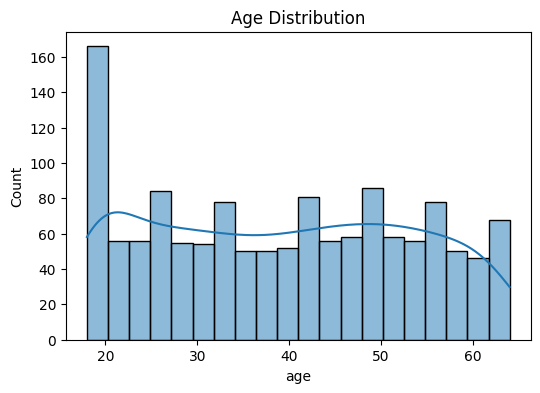

In [30]:
#5 تحليل البيانات بالرسم البياني(Data Visulzation)

#توزيع الأعمار
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

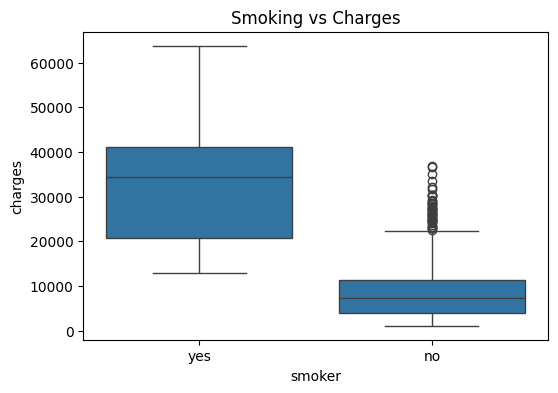

In [9]:
#تأثير التدخين على التكلفة
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Smoking vs Charges')
plt.show

#المدخنون لديهم تكلفة تأمين أعلى بكثير
#وهذا يعتبر من أهم العوامل المؤثرة

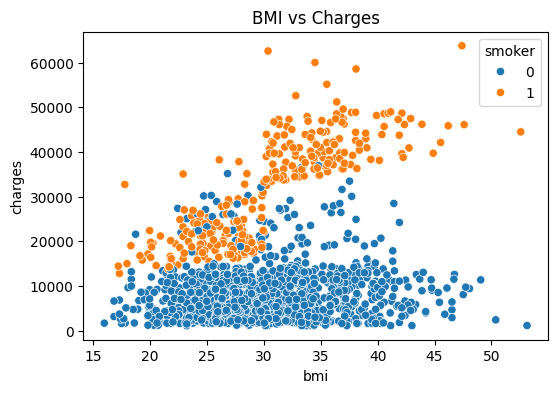

In [32]:
#العلاقة بين BMI والتكلفة
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs Charges')
plt.show()
#كلما زاد BMI زادت التكلفة خصوصاً عند المدخنين

In [33]:
#6 معالجة البيانات (Preprocessing)
#نماذج التعلم الآلي لا تفهم النصوص.

#لذلك نحول:
#male/female
#yes/no
#المناطق

le = LabelEncoder()

# تحويل الأعمدة النصية
for col in ['sex', 'smoker', 'region']: #text
    df[col] = le.fit_transform(df[col])

In [34]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [15]:
#7 تحديد المدخلات والمخرجات
#X = Features

#هي الأعمدة المستخدمة للتنبؤ.
#y = Target /lable


X = df.drop('charges', axis=1)
y = df['charges']

In [16]:
#8 تقسيم البيانات

#نقسم البيانات إلى:

#Training Data → للتعلم
#Testing Data → للاختبار

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#معنى test_size=0.2
#80% تدريب(train)
#
#20% اختبار (test)

In [35]:
#9 بناء نموذج التعلم الآلي
#Linear Regression
model = LinearRegression()


In [36]:
#تدريب النموذج
model.fit(X_train, y_train)

LinearRegression()

In [41]:
#10 التنبؤ
y_pred = model.predict(X_test)

In [42]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(result.head())



           Actual     Predicted
764    9095.06825   8924.407244
887    5272.17580   7116.295018
890   29330.98315  36909.013521
1293   9301.89355   9507.874691
259   33750.29180  27013.350008


In [23]:
#11 تقييم النموذج
#Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)

MAE: 4186.508898366433


##ماذا يعني؟

##متوسط الفرق بين القيمة الحقيقية والمتوقعة.

##كلما كان أقل كان النموذج أفضل.

In [25]:
#Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

MSE: 33635210.431178406


In [26]:
#Root Mean Squared Error
rmse = np.sqrt(mse)
print('RMSE:', rmse)

RMSE: 5799.587091438356


In [27]:
#R² Score
r2 = r2_score(y_test, y_pred)
print('R2 Score:', r2)

R2 Score: 0.7833463107364539


شرح R²

يقيس مدى جودة النموذج.

قريب من 1 → ممتاز
قريب من 0 → ضعيف

In [43]:
#12 معرفة العوامل الأكثر تأثيراً
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

#التدخين أكثر عامل مؤثر.
#العمر يؤثر بشكل واضح.
#BMI يؤثر أيضاً.

    Feature   Coefficient
0       age    257.056264
1       sex    -18.791457
2       bmi    335.781491
3  children    425.091456
4    smoker  23647.818096
5    region   -271.284266


In [45]:
#13 تجربة بيانات جديدة للتنبؤ
new_data = pd.DataFrame({
    'age': [30],
    'sex': [1],
    'bmi': [28.5],
    'children': [2],
    'smoker': [0],
    'region': [1]
})

prediction = model.predict(new_data)

print('Predicted Insurance Charges:', prediction)

Predicted Insurance Charges: [5894.96102461]


##أهم النتائج من التحليل
##التدخين هو العامل الأقوى في رفع تكلفة التأمين.
##زيادة BMI ترتبط بزيادة التكاليف.
##العمر له تأثير واضح على التكاليف.
##نموذج Linear Regression أعطى أداء جيد للتنبؤ.

##قراءة البيانات.
##فهم الأعمدة.
##تحليل البيانات بالرسم.
##تنظيف وتجهيز البيانات.
##تحويل النصوص لأرقام.
##تقسيم البيانات.
##بناء نموذج تعلم آلة.
##تدريب النموذج.
##التنبؤ بالنتائج.
##تقييم أداء النموذج.